In [26]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    # messages有列表信息，以及一个add_message函数
    # 在annotation中定义了state的更新方式
    # 在这个例子中，message是被添加到list中，而不是每次都覆盖
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [27]:
import os
import httpx
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

# 加载环境变量（推荐把密钥放到 .env 文件中）
load_dotenv()

BASE_URL = os.getenv("OPENAI_BASE_URL")
API_KEY = os.getenv("OPENAI_API_KEY", "")
MODEL = os.getenv("OPENAI_MODEL", "deepseek")

# 如果使用自签名证书或 IP 直连，可关闭校验
transport = httpx.HTTPTransport(verify=False)
http_client = httpx.Client(transport=transport)

llm = ChatOpenAI(
    base_url=BASE_URL,
    api_key=API_KEY,
    model=MODEL,
    http_client=http_client,
    streaming=True,
)

In [28]:
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

# 第一个参数是节点名称
# 第二个参数是具体被调用的函数，跟随节点名称被调用
graph_builder.add_node("chatbot", chatbot)

In [29]:
graph_builder.add_edge(START, "chatbot")

In [30]:
graph_builder.add_edge("chatbot", END)

In [31]:
graph = graph_builder.compile()

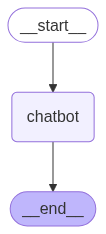

In [32]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [33]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        stream_graph_updates(user_input)
    except Exception:
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

Assistant: I'm currently running version **1.0**. Let me know how I can assist you! 😊
Assistant: I’m **DeepSeek Chat**, an AI assistant created by **DeepSeek**. My current version is **DeepSeek-V3**, and my knowledge is up to date until **July 2024**.  

I can help with a wide range of topics, including answering questions, summarizing documents, generating creative content, and assisting with coding. I also support **128K context length**, meaning I can handle long conversations and large documents effectively.  

Let me know how I can assist you! 😊
User: What do you know about LangGraph?


KeyboardInterrupt: 